# Ноутбук для решения задачи урока 5.1


In [ ]:
# Импортируем датасет

import pandas as pd

df = pd.read_csv("https://stepik.org/media/attachments/lesson/1028705/mulimodal_questions.csv")
df

In [ ]:
# Установим необходимую версию библиотеки

!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 MB 8.9 MB/s eta 0:00:00


In [ ]:
# Скачаем zip-архив с картинками

!wget https://stepik.org/media/attachments/lesson/1028705/images.zip
!unzip images.zip

--2024-08-02 20:21:33--  https://stepik.org/media/attachments/lesson/1028705/images.zip
Resolving stepik.org (stepik.org)... 178.248.239.111
Connecting to stepik.org (stepik.org)|178.248.239.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 737243 (720K) [application/zip]
Saving to: ‘images.zip.1’

images.zip.1        100%[===================>] 719.96K   520KB/s    in 1.4s    

2024-08-02 20:21:36 (520 KB/s) - ‘images.zip.1’ saved [737243/737243]

Archive:  images.zip
   creating: images/
  inflating: images/im1.jpg          
  inflating: images/im8.jpg          
  inflating: images/im4.jpg          
  inflating: images/im7.jpg          
  inflating: images/im6.jpg          
  inflating: images/im2.jpg          
  inflating: images/im5.jpg          
  inflating: images/im9.jpg          
  inflating: images/im3.jpg          
  inflating: images/im0.jpg          


In [ ]:
from PIL import Image
import torch
from transformers import pipeline
from transformers import BitsAndBytesConfig

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True, # подгружаем сразу оптимальную версию
    bnb_4bit_compute_dtype=torch.float16
)

In [ ]:
# указываем тип задачи и модель (рекомендуем llava)
model_id = "llava-hf/llava-1.5-7b-hf"

pipe = pipeline("image-text-to-text", model=model_id, model_kwargs={"quantization_config": quantization_config})

In [ ]:
images = [f"images/{name}" for name in df['image_name'].values]

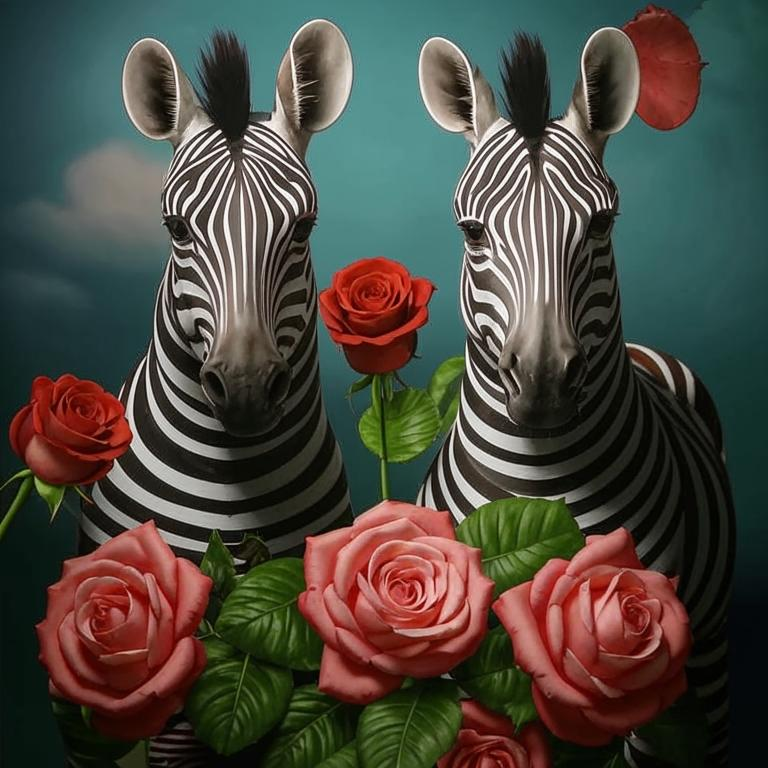

In [ ]:
# Посмотрим первое изображение
Image.open(images[0])

In [ ]:
# Получим предсказания для изображений
import re

ans = []
for im_path, question in zip(images, df['question'].values):
    messages = [{"role": "user", "content": [
        {"type": "image", "url": im_path},
        {"type": "text", "text": question + " Answer with a single integer number only."}
    ]}]
    outputs = pipe(text=messages, generate_kwargs={"max_new_tokens": 200})
    raw = outputs[0]['generated_text'][-1]['content']
    nums = re.findall(r'\d+', raw)
    ans.append(int(nums[0]) if nums else 0)
print(ans)

In [ ]:
# запишем ответы в датафрейм
df['answer'] = ans
df.drop(columns=['image_name']).to_csv('m5fine_tuning_solution.csv', index=False)
df